# Test d'un AFC sur un corpus de textes en français avec auteur naturaliste et non naturaliste

In [1]:
import os   
import pandas as pd 
import spacy
import matplotlib.pyplot as plt
from fanalysis.ca import CA
from sklearn.feature_extraction.text import CountVectorizer
from scipy.spatial import distance_matrix
from scipy.cluster.hierarchy import dendrogram, linkage

## Chargement des données (dans le fichier data)

In [2]:
dossier = "DATA"
documents = []
titres = []

# On boucle sur tous les fichiers texte du dossier
for fichier in os.listdir(dossier):
    if fichier.endswith(".txt"):
        titres.append(fichier.replace(".txt", ""))
        # Lecture avec encodage utf-8 pour le français
        with open(os.path.join(dossier, fichier), 'r', encoding='utf-8') as f:
            documents.append(f.read())

print(f"{len(documents)} textes chargés avec succès.")

16 textes chargés avec succès.


In [3]:
nlp = spacy.load("fr_core_news_lg")
mots_vides_fr = list(nlp.Defaults.stop_words)

# Début ACF (analyse en Composantes Factorielles)

### Préparation de la matrice de documents

In [4]:
vectorizer = CountVectorizer(stop_words=mots_vides_fr, min_df=3, max_df=0.8, max_features=3000)
X = vectorizer.fit_transform(documents)

/Users/morganr/AFC-Naturalisme/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


In [5]:
valeurs = X.toarray()
etiquettes_textes = titres
etiquettes_mots = vectorizer.get_feature_names_out()

### Paramètres de l'AFC

In [6]:
afc = CA(row_labels=etiquettes_textes, col_labels=etiquettes_mots)
afc.fit(valeurs)

,row_labels,"['1887_Bloy_Desespere_C', '1889_ Descaves_SousOffs_C', ...]"
,col_labels,"array(['14', ... dtype=object)"
,n_components,None
,stats,True
Name,Type,Value
c_,"ndarray[int64](1, 3000)","[[21,52,38,...,24,39,39]]"
col_contrib_,"ndarray[float64](3000, 15)","[[0.02,0.01,0.01,...,0. ,0.01,0. ], [0.02,0.01,0. ,...,0. ,0.03,0.01], [0. ,0. ,0.02,...,0.05,0. ,0.03], ..., [0.03,0. ,0.02,...,0.01,0. ,0.01], [0. ,0. ,0.02,...,0.17,0. ,0.06], [0. ,0. ,0.03,...,0. ,0.27,0.05]]"
col_coord_,"ndarray[float64](3000, 15)","[[ 0.6 , 0.33, 0.32,..., 0.14, 0.19, 0.06], [ 0.3 , 0.24,-0.05,...,-0.06, 0.22, 0.13], [ 0.17,-0.14,-0.37,...,-0.38,-0.09, 0.25], ..., [-0.59,-0.23, 0.47,...,-0.16, 0.1 , 0.13], [ 0.02, 0.11,-0.32,...,-0.71,-0.06, 0.35], [ 0.01,-0.17,-0.45,..., 0.06, 0.81, 0.31]]"
col_cos2_,"ndarray[float64](3000, 15)","[[0.25,0.08,0.07,...,0.01,0.03,0. ], [0.09,0.05,0. ,...,0. ,0.05,0.02], [0.02,0.01,0.09,...,0.09,0.01,0.04], ..., [0.25,0.04,0.16,...,0.02,0.01,0.01], [0. ,0.01,0.09,...,0.43,0. ,0.1 ], [0. ,0.01,0.07,...,0. ,0.21,0.03]]"
col_labels_,"ndarray[object](3000,)","['14','abandon','abandonna',...,'ôter','œufs','œuvres']"
col_labels_short_,"ndarray[object](3000,)","['14','abandon','abandonna',...,'ôter','œufs','œuvres']"


### Visualisation des contributions des mots

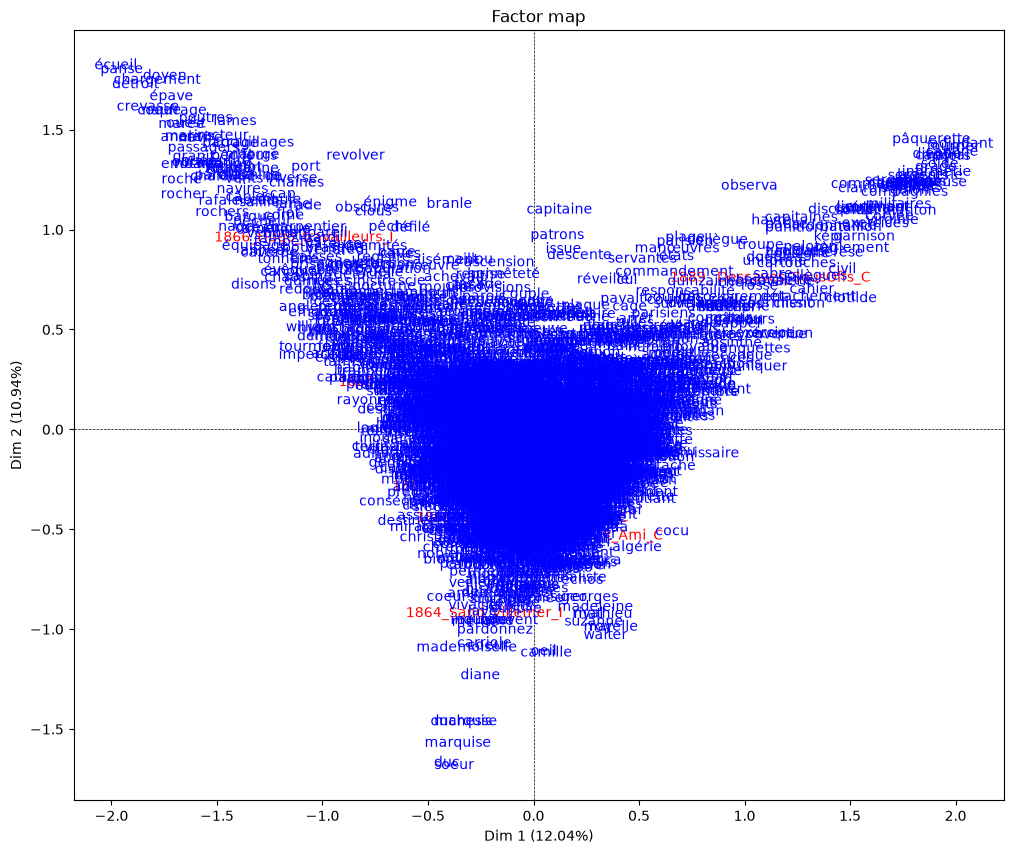

In [7]:
afc.mapping(num_x_axis=1, num_y_axis=2, figsize=(12, 10))
plt.show()

In [8]:
# 1. Extraction des contributions (en pourcentages)
contributions_mots = afc.col_contrib_

# 2. Création du DataFrame global
df_contrib = pd.DataFrame({
    'Mot': etiquettes_mots,
    'Contrib_Axe1': contributions_mots[:, 0], # Index 0 = Axe 1
    'Contrib_Axe2': contributions_mots[:, 1]  # Index 1 = Axe 2
})

# 3. Extraction du Top 15 pour l'Axe 1
top_axe1 = df_contrib.sort_values(by='Contrib_Axe1', ascending=False).head(15)

# 4. Extraction du Top 15 pour l'Axe 2
top_axe2 = df_contrib.sort_values(by='Contrib_Axe2', ascending=False).head(15)

# Affichage des résultats
print("--- TOP 15 : MOTS STRUCTURANT L'AXE 1 ---")
print(top_axe1[['Mot', 'Contrib_Axe1']])

print("\n--- TOP 15 : MOTS STRUCTURANT L'AXE 2 ---")
print(top_axe2[['Mot', 'Contrib_Axe2']])

--- TOP 15 : MOTS STRUCTURANT L'AXE 1 ---
            Mot  Contrib_Axe1
1817  officiers      2.883255
1269  généreuse      2.386391
2494    sergent      2.258179
1587      major      1.833865
41     adjudant      1.734585
1867      panse      1.727319
2914     écueil      1.602694
418     caserne      1.465849
2540     soldat      1.366734
2342     rocher      1.349998
1177   fourrier      1.241519
1578    machine      1.143739
559     colonel      1.110084
1748     navire      1.058390
2495   sergents      1.019867

--- TOP 15 : MOTS STRUCTURANT L'AXE 2 ---
            Mot  Contrib_Axe2
1620    marquis      3.314243
864         duc      3.136002
1621   marquise      2.115332
1867      panse      1.619500
2914     écueil      1.493819
1817  officiers      1.470191
2494    sergent      1.333497
547       coeur      1.161317
1269  généreuse      1.138745
1578    machine      1.120464
1669        mme      1.077943
403   capitaine      1.062298
1748     navire      0.995969
1587      major

In [68]:
coords_textes = afc.row_coord_[:, :2]

# On met ça au propre dans un DataFrame
df_textes = pd.DataFrame({
    'Texte': etiquettes_textes,
    'Coord_Axe1': coords_textes[:, 0],
    'Coord_Axe2': coords_textes[:, 1]
}).set_index('Texte')

print("--- POSITION DES TEXTES SUR LES AXES 1 ET 2 ---")
print(df_textes.head(16))

--- POSITION DES TEXTES SUR LES AXES 1 ET 2 ---
                            Coord_Axe1  Coord_Axe2
Texte                                             
1887_Bloy_Desespere_C        -0.258126   -0.286146
1889_ Descaves_SousOffs_C     1.122367    0.758485
1886_Husymans_rade_C         -0.114302    0.173672
1885_Maupassant_Ami_C         0.188636   -0.532847
1884_Alis_Soleil_C           -0.053909   -0.204939
1860_Goncourt_Demailly_I      0.017784   -0.306700
1883_Bonnetain_Charlot_C      0.132918    0.069694
1886_Valles_Insurge_C         0.278073    0.158307
1869_Flaubert_education_I     0.127864   -0.211905
1886_Rosny_Horn_C            -0.159041    0.070060
1866_Hugo_travailleurs_I     -1.088367    0.959655
1883_Cherbuliez_Choquard_C   -0.053227   -0.443338
1857_Flaubert_Bovary_I        0.033537   -0.212494
1864_Sand_Villemer_I         -0.234012   -0.920524
1865_Gautier_Jenny_I         -0.561057    0.235865
1885_Adam_molle_C             0.230146   -0.080959


In [69]:
print("Voici les textes actuellement chargés dans le corpus :")
for i, titre in enumerate(titres):
    print(f"{i} : {titre}")

Voici les textes actuellement chargés dans le corpus :
0 : 1887_Bloy_Desespere_C
1 : 1889_ Descaves_SousOffs_C
2 : 1886_Husymans_rade_C
3 : 1885_Maupassant_Ami_C
4 : 1884_Alis_Soleil_C
5 : 1860_Goncourt_Demailly_I
6 : 1883_Bonnetain_Charlot_C
7 : 1886_Valles_Insurge_C
8 : 1869_Flaubert_education_I
9 : 1886_Rosny_Horn_C
10 : 1866_Hugo_travailleurs_I
11 : 1883_Cherbuliez_Choquard_C
12 : 1857_Flaubert_Bovary_I
13 : 1864_Sand_Villemer_I
14 : 1865_Gautier_Jenny_I
15 : 1885_Adam_molle_C


In [72]:
matrice_dist = distance_matrix(coords_textes, coords_textes)

# On transforme ça en tableau lisible avec le nom des textes en lignes et colonnes
df_distances = pd.DataFrame(
    matrice_dist, 
    index=etiquettes_textes, 
    columns=etiquettes_textes
)

# Exemple : Trouvons les 3 textes les plus proches du premier texte de ta liste
# (On exclut le premier résultat car la distance d'un texte avec lui-même est toujours de 0)
texte_cible = etiquettes_textes[8] 

voisins = df_distances[texte_cible].sort_values()[1:6]

print(f"\n--- TEXTES LES PLUS PROCHES DE '{texte_cible}' ---")
print(voisins)


--- TEXTES LES PLUS PROCHES DE '1869_Flaubert_education_I' ---
1857_Flaubert_Bovary_I        1.503277
1883_Cherbuliez_Choquard_C    1.695532
1886_Rosny_Horn_C             1.742435
1885_Maupassant_Ami_C         1.818877
1860_Goncourt_Demailly_I      1.836887
Name: 1869_Flaubert_education_I, dtype: float64


/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/1278326766.py:1: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)
/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/1278326766.py:1: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)
/var/folders/nw/xxpy5wzj7hv7n2gtbzf6pz180000gn/T/ipykernel_45140/1278326766.py:1: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  matrice_dist = distance_matrix(coords_textes, coords_textes)


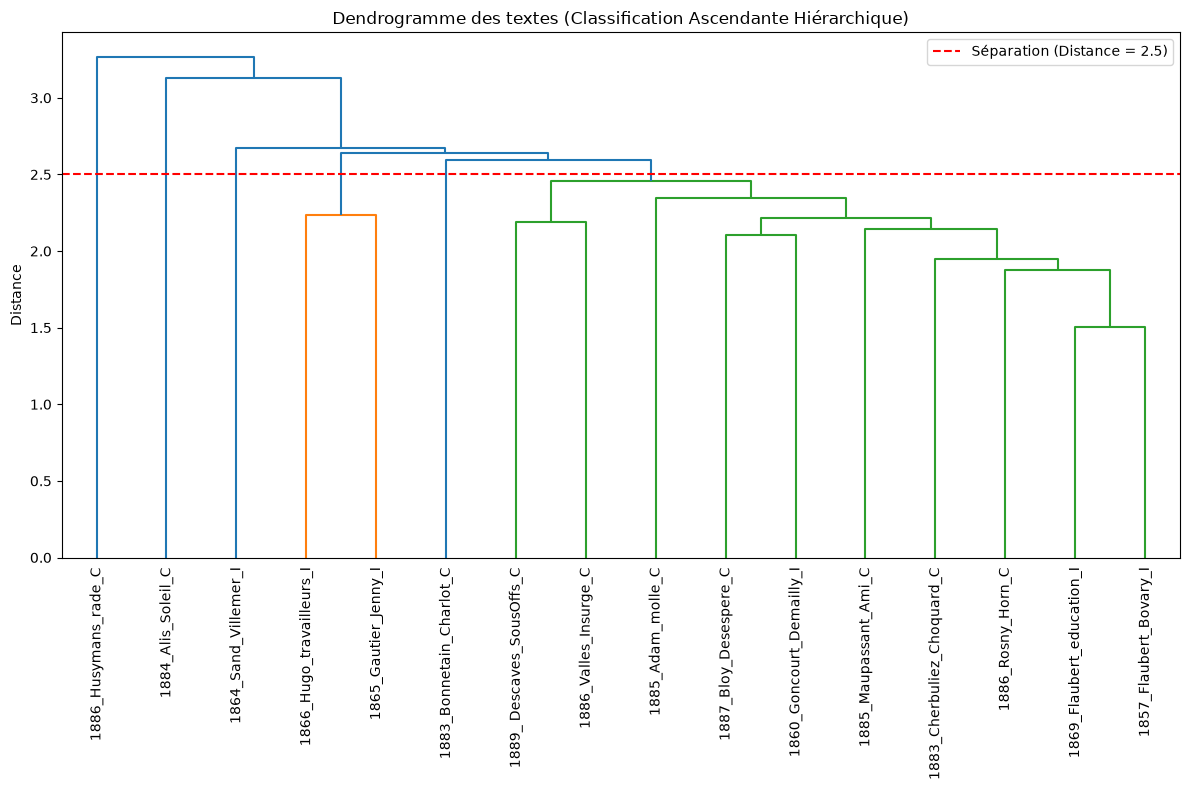

In [71]:
coords_textes = afc.row_coord_

# 2. Calcul des regroupements (linkage)
Z = linkage(coords_textes, method='ward')
seuil_coupe = 2.5 

# 3. Paramétrage et affichage du dendrogramme
plt.figure(figsize=(12, 8))
plt.title("Dendrogramme des textes (Classification Ascendante Hiérarchique)")
plt.ylabel("Distance")

# Génération de l'arbre
dendrogram(
    Z, 
    labels=etiquettes_textes, 
    leaf_rotation=90,         
    leaf_font_size=10,
    color_threshold=seuil_coupe # Les couleurs changent sous ce seuil
)

plt.axhline(y=seuil_coupe, color='r', linestyle='--', label=f'Séparation (Distance = {seuil_coupe})')
plt.legend()
plt.tight_layout()
plt.show()